Nei codici Monte Carlo come OpenMC, i risultati dei tally sono intrinsecamente normalizzati
per particella di sorgente simulata. Nello Step 1 la tua sorgente era un singolo fotone. 
Il tally di corrente (current_a) misurava i neutroni che attraversavano la superficie esterna del target. 
Di conseguenza, la loro somma totale, ovvero sum_a, rappresenta la resa fotoneutronica integrale del bersaglio.
Fisicamente, sum_a risponde alla domanda: "Quanti neutroni utili ottengo per ogni singolo fotone 
primario emesso dal sincrotrone?" (Troverai un valore molto minore di 1, tipicamente dell'ordine di 0.01).


Lettura di:  statepoint.30b.50000000p.h5
Dati estratti con successo.
Yield fotoneutronico calcolato (energia): 5.87905e-03 neutroni / fotone sorgente
Yield fotoneutronico calcolato (angolo): 5.87905e-03 neutroni / fotone sorgente


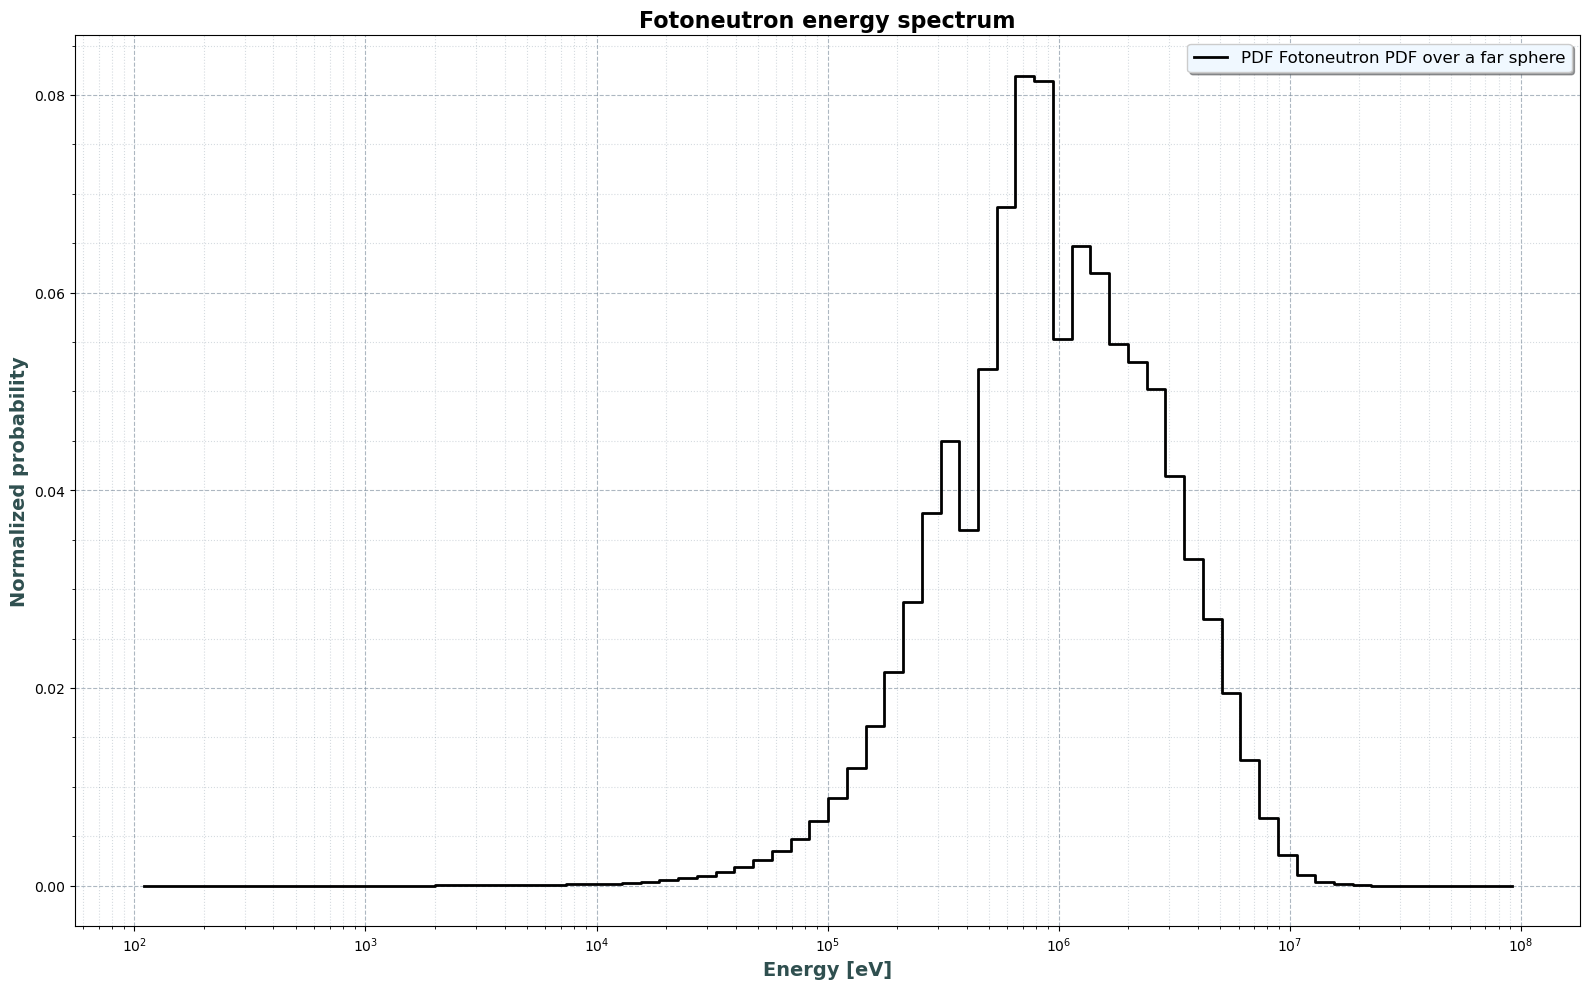

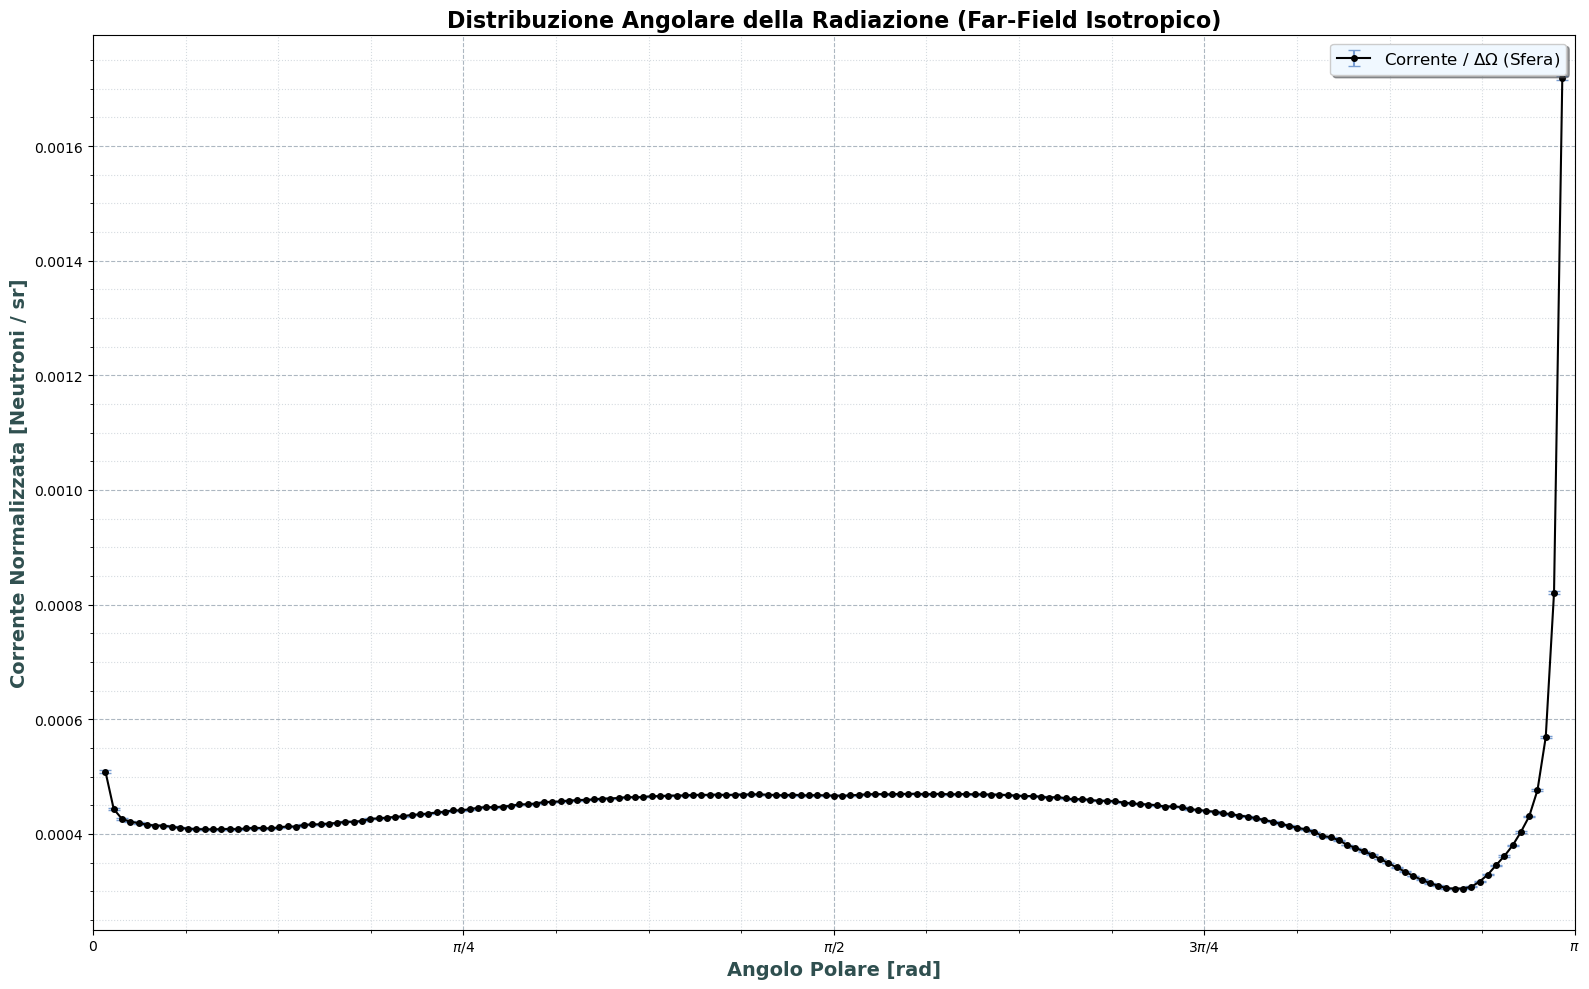

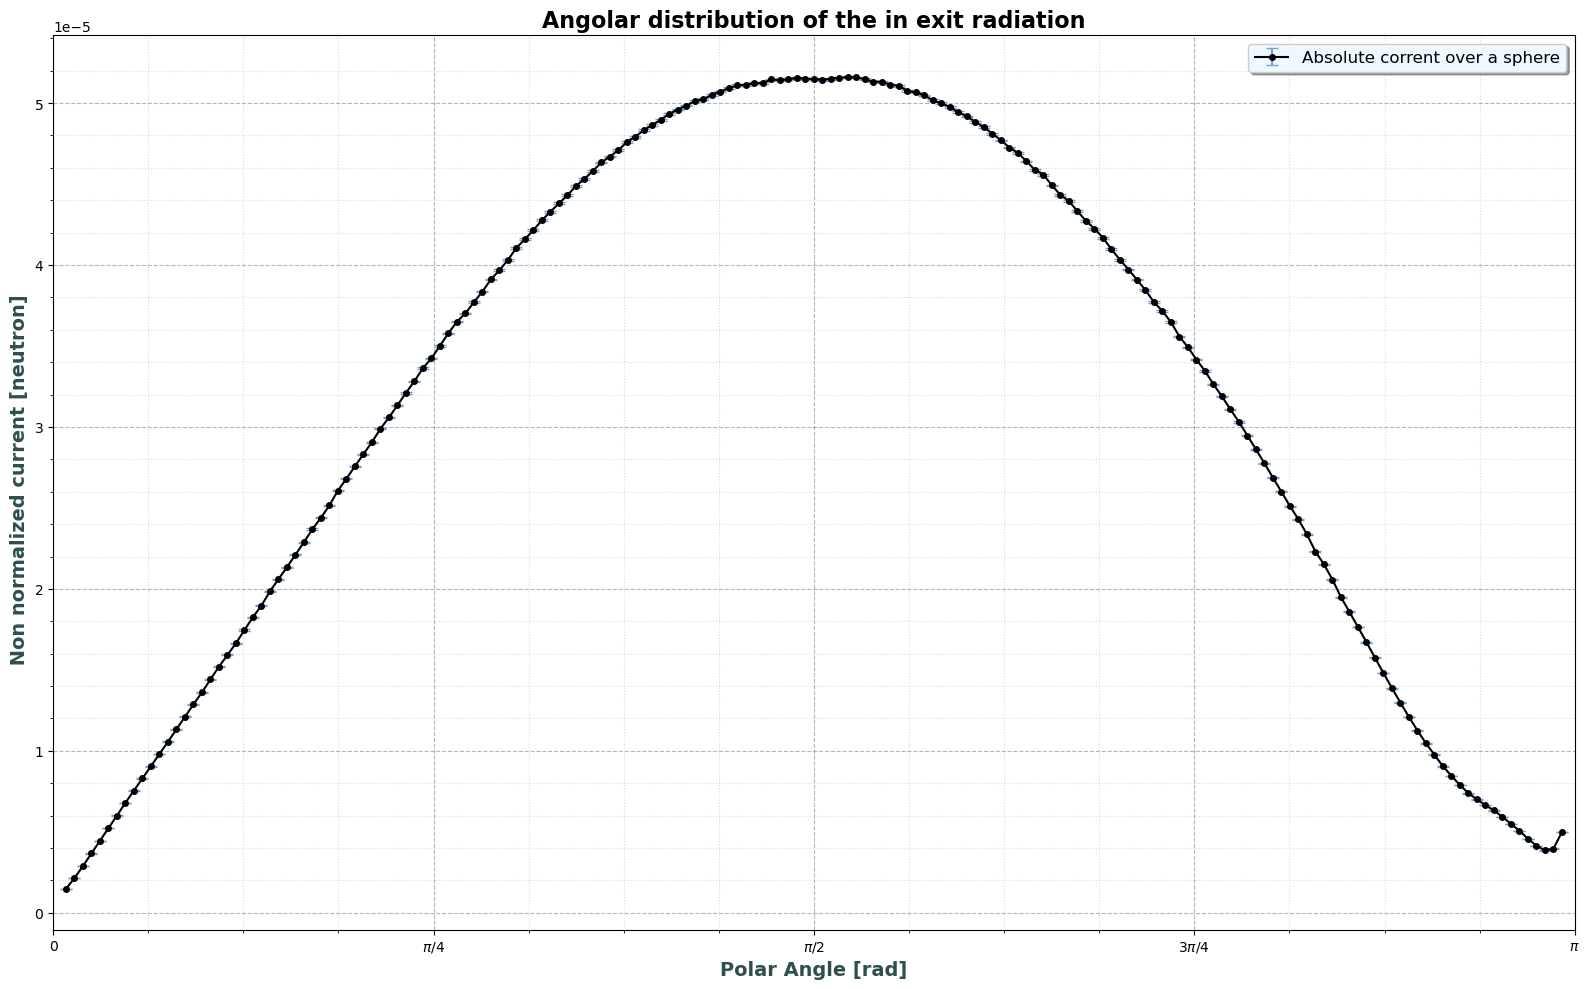

In [1]:
import os
import glob
import openmc
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. SETUP BIN E CALCOLI GEOMETRICI
# =====================================================================

energy_bins = np.logspace(2, 8, 75)
polar_bins = np.linspace(0, np.pi, 180)

# Calcolo dei centri dei bin
energy_midpoints = np.sqrt(energy_bins[:-1] * energy_bins[1:])
polar_midpoints = 0.5 * (polar_bins[:-1] + polar_bins[1:])

# Angolo solido per normalizzazione isotropia (Sfera)
solid_angles = 2 * np.pi * (np.cos(polar_bins[:-1]) - np.cos(polar_bins[1:]))

# =====================================================================
# 2. ESTRAZIONE DATI TALLIES
# =====================================================================

sp_files = glob.glob('statepoint.*.h5')

if not sp_files:
    raise FileNotFoundError("Nessun file statepoint trovato.")
latest_sp = max(sp_files, key=os.path.getctime)
print("Lettura di: ", latest_sp)

with openmc.StatePoint(latest_sp) as sp:
    # --- Tally: Spettro Energetico (Sfera) ---
    t_e = sp.get_tally(name='distribuzione_energy_sfera')
    current_e = np.abs(t_e.mean.flatten())
    std_e = t_e.std_dev.flatten()

    # --- Tally: Isotropia (Sfera di controllo) ---
    t_iso = sp.get_tally(name='distribuzione_ang_sfera')
    current_iso = np.abs(t_iso.mean.flatten())
    std_iso = t_iso.std_dev.flatten()

# =====================================================================
# 3. YIELD E NORMALIZZAZIONI
# =====================================================================

# Lo yield totale è l'integrale della corrente uscente su tutto lo spettro
yield_totale_e = np.sum(current_e) 

# Normalizzazione a Probabilità Discreta (PMF/PDF)
pdf_e = current_e / yield_totale_e 
std_pdf_e = std_e / yield_totale_e 

# Normalizzazione sull'angolo solido per verifica isotropia
norm_iso_mean = current_iso / solid_angles
norm_iso_std = std_iso / solid_angles

print(f"Dati estratti con successo.")
print(f"Yield fotoneutronico calcolato (energia): {yield_totale_e:.5e} neutroni / fotone sorgente")
print(f"Yield fotoneutronico calcolato (angolo): {np.sum(current_iso):.5e} neutroni / fotone sorgente")

# =====================================================================
# 4. PLOTTING DEI RISULTATI
# =====================================================================

# Taglio i bordi estremi se ci sono divergenze ai poli
polar_mid_cut = polar_midpoints[1:-1]
current_iso_cut = current_iso[1:-1]
norm_iso_mean_cut = norm_iso_mean[1:-1]
norm_iso_std_cut = norm_iso_std[1:-1]
std_iso_cut = std_iso[1:-1]

def apply_custom_style(ax, title, xlabel, ylabel):
    """Applica lo stile standard unificato ai plot."""
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.set_ylabel(ylabel, fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.minorticks_on()
    ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
    ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
    ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

# --- PLOT 1: Spettro Energetico ---

fig1, ax1 = plt.subplots(figsize=(16, 10))
ax1.step(energy_midpoints, pdf_e, where='mid', color='#000000', lw=2, label='PDF Fotoneutron PDF over a far sphere')
ax1.set_xscale('log')
apply_custom_style(ax1, "Fotoneutron energy spectrum", "Energy [eV]", "Normalized probability")
plt.tight_layout()
plt.show()

# --- PLOT 2: Verifica Isotropia (Sfera Far-Field Normalizzata) ---
fig2, ax2 = plt.subplots(figsize=(16, 10))
ax2.errorbar(polar_mid_cut, norm_iso_mean_cut, yerr=norm_iso_std_cut, 
             fmt='o-', color='#000000', ecolor='#789DD1', capsize=4, markersize=4,
             label=r'Corrente / $\Delta\Omega$ (Sfera)')
ax2.set_xlim(0, np.pi)
ax2.set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax2.set_xticklabels(['0', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])
apply_custom_style(ax2, "Distribuzione Angolare della Radiazione (Far-Field Isotropico)", "Angolo Polare [rad]", "Corrente Normalizzata [Neutroni / sr]")
plt.tight_layout()
plt.show()

# --- PLOT 3: Verifica Isotropia (Corrente Assoluta) ---
fig3, ax3 = plt.subplots(figsize=(16, 10))
ax3.errorbar(polar_mid_cut, current_iso_cut, yerr=std_iso_cut, 
             fmt='o-', color='#000000', ecolor='#789DD1', capsize=4, markersize=4, 
             label='Absolute corrent over a sphere')
ax3.set_xlim(0, np.pi)
ax3.set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax3.set_xticklabels(['0', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])
apply_custom_style(ax3, "Angolar distribution of the in exit radiation", "Polar Angle [rad]", " Non normalized current [neutron]")
plt.tight_layout()
plt.show()

In [8]:
#per il plot 2

#Zona piatta: L'andamento costante nella regione centrale è la prova fisica che l'emissione è spazialmente isotropa. Rimuovendo il fattore puramente geometrico, il flusso risulta omogeneo in tutte le direzioni.Divergenza ai poli ($0$ e $\pi$): È un noto artefatto statistico/numerico del binning polare Monte Carlo. Avvicinandosi ai poli, il termine $d\Omega$ tende a zero. La divisione di un conteggio MC affetto da incertezza statistica per un divisore infinitesimo fa esplodere il valore e l'errore. La divergenz
#a non ha significato fisico ed è il motivo per cui è prassi escludere i bin polari estremi dal plot.

In [11]:
# Salvataggio Energia: Energia | PDF | Errore PDF
np.savetxt(
    "photoneutrons_energy.txt", 
    np.column_stack((energy_midpoints, pdf_e, std_pdf_e)), 
    header="Energy_eV PDF Error_PDF", 
    comments="", 
    fmt='%.8e'
)

# Salvataggio Angolo: Angolo | Corrente | Errore Corrente
np.savetxt(
    "photoneutrons_polar.txt", 
    np.column_stack((polar_mid_cut, current_iso_cut, std_iso_cut)), 
    header="Angle_rad Current Error_Current", 
    comments="", 
    fmt='%.8e'
)

print("Dati e relativi errori salvati correttamente nei file .txt")


Dati e relativi errori salvati correttamente nei file .txt
